# HOUSE PRICING PREDICTIONS

In [1]:
# READING THE DATASET
import pandas as pd

house_df = pd.read_csv('./house_price.csv')
house_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [3]:
pd.set_option('display.max_rows',None)

In [4]:
# checking for null values
house_df.isna().sum()

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

* OBSERVATION : THIS TIME I AM USING SIMPLE IMPUTER FOR NUMERICAL COLUMNS AND FILLNA FOR CATEGORICAL COLUMNS. TO FILL IN THE NULL VALUES

* OBSERVATION : DROPPING UNNECESSARY COLUMNS

In [5]:
house_df.drop(columns=['Alley','PoolQC','Fence','MiscFeature'],axis=1,inplace=True)

* VISUALIZATION BASED ON YEAR

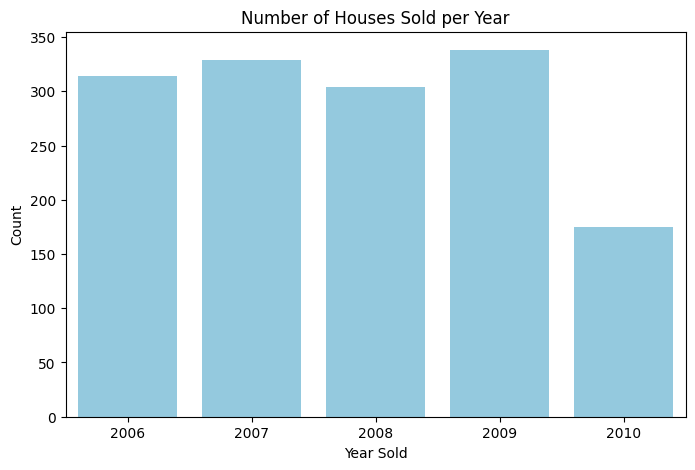

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x='YrSold', data=house_df, color='skyblue')
plt.title('Number of Houses Sold per Year')
plt.xlabel('Year Sold')
plt.ylabel('Count')
plt.show()


In [7]:
house_df.drop('MoSold',axis=1,inplace=True)

In [8]:
year = house_df['YrSold']

* DIVIDING THE DATA BASED ON YEAR

In [9]:
train_df = house_df[year > 2009]
val_df = house_df[year == 2009]
test_df = house_df[year < 2009]

In [10]:
input_cols = list(train_df.columns)[1:-1] # give me every columns except the first and last 
target_cols = 'SalePrice'

copying mean you are not interfering with the original dataset

In [11]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_cols].copy()

test_inputs = test_df[input_cols].copy()
test_targets = test_df[target_cols].copy()

val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_cols].copy()

In [12]:
import numpy as np
numeric_cols = train_inputs.select_dtypes(include = np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()


In [13]:
train_inputs[numeric_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 175 entries, 16 to 1458
Data columns (total 35 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     175 non-null    int64  
 1   LotFrontage    143 non-null    float64
 2   LotArea        175 non-null    int64  
 3   OverallQual    175 non-null    int64  
 4   OverallCond    175 non-null    int64  
 5   YearBuilt      175 non-null    int64  
 6   YearRemodAdd   175 non-null    int64  
 7   MasVnrArea     174 non-null    float64
 8   BsmtFinSF1     175 non-null    int64  
 9   BsmtFinSF2     175 non-null    int64  
 10  BsmtUnfSF      175 non-null    int64  
 11  TotalBsmtSF    175 non-null    int64  
 12  1stFlrSF       175 non-null    int64  
 13  2ndFlrSF       175 non-null    int64  
 14  LowQualFinSF   175 non-null    int64  
 15  GrLivArea      175 non-null    int64  
 16  BsmtFullBath   175 non-null    int64  
 17  BsmtHalfBath   175 non-null    int64  
 18  FullBath     

In [14]:

train_inputs[categorical_cols].isna().sum()

MSZoning           0
Street             0
LotShape           0
LandContour        0
Utilities          0
LotConfig          0
LandSlope          0
Neighborhood       0
Condition1         0
Condition2         0
BldgType           0
HouseStyle         0
RoofStyle          0
RoofMatl           0
Exterior1st        0
Exterior2nd        0
MasVnrType       105
ExterQual          0
ExterCond          0
Foundation         0
BsmtQual           5
BsmtCond           5
BsmtExposure       5
BsmtFinType1       5
BsmtFinType2       5
Heating            0
HeatingQC          0
CentralAir         0
Electrical         0
KitchenQual        0
Functional         0
FireplaceQu       93
GarageType        11
GarageFinish      11
GarageQual        11
GarageCond        11
PavedDrive         0
SaleType           0
SaleCondition      0
dtype: int64

In [15]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
train_inputs_imp = imputer.fit_transform(train_inputs[numeric_cols])
test_inputs_imp = imputer.transform(test_inputs[numeric_cols])
val_inputs_imp = imputer.transform(val_inputs[numeric_cols])

In [16]:
train_inputs[categorical_cols] = train_inputs[categorical_cols].fillna('Unknown')
val_inputs[categorical_cols]   = val_inputs[categorical_cols].fillna('Unknown')
test_inputs[categorical_cols]  = test_inputs[categorical_cols].fillna('Unknown')


In [17]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

train_inputs_end = encoder.fit_transform(train_inputs[categorical_cols])
test_inputs_end = encoder.transform(test_inputs[categorical_cols])
val_inputs_end = encoder.transform(val_inputs[categorical_cols])

* MERGING THE TWO 

In [18]:
X_train_final = np.hstack([train_inputs_imp,train_inputs_end])
X_test_final = np.hstack([test_inputs_imp,test_inputs_end])
X_val_final = np.hstack([val_inputs_imp,val_inputs_end])

* TRAINING A MODEL

In [19]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42,
                              n_estimators=200,
                              n_jobs=-1)
model.fit(X_train_final,train_targets)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
model.score(X_train_final,train_targets)

0.9713408660224543

In [21]:
train_pred = model.predict(X_train_final)
val_pred = model.predict(X_val_final)
test_pred = model.predict(X_test_final)

In [22]:
val_score = model.score(X_val_final,val_targets)
test_score = model.score(X_test_final,test_targets)

print(f"The validation score is {val_score}")
print(f"The test score is : {test_score}")

The validation score is 0.839325964301296
The test score is : 0.7661671810899039


In [23]:
from sklearn.metrics import mean_squared_error

train_rmse = np.sqrt(mean_squared_error(train_targets,train_pred))
test_rmse = np.sqrt(mean_squared_error(test_targets,test_pred))
val_rmse = np.sqrt(mean_squared_error(val_targets,val_pred))

print(f"The train rmse score : {train_rmse}")
print(f"The test rmse score : {test_rmse}")
print(f"The val rmse score : {val_rmse}")

The train rmse score : 13580.635400101195
The test rmse score : 38080.915204469435
The val rmse score : 32371.773912682725


In [24]:
numeric_features = list(numeric_cols)
categorical_features = encoder.get_feature_names_out(categorical_cols)

features_name = numeric_features + list(categorical_features)

print(features_name)

['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'YrSold', 'MSZoning_C (all)', 'MSZoning_FV', 'MSZoning_RL', 'MSZoning_RM', 'Street_Grvl', 'Street_Pave', 'LotShape_IR1', 'LotShape_IR2', 'LotShape_Reg', 'LandContour_Bnk', 'LandContour_HLS', 'LandContour_Low', 'LandContour_Lvl', 'Utilities_AllPub', 'LotConfig_Corner', 'LotConfig_CulDSac', 'LotConfig_FR2', 'LotConfig_Inside', 'LandSlope_Gtl', 'LandSlope_Mod', 'LandSlope_Sev', 'Neighborhood_Blmngtn', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor'

In [25]:
importance_df = pd.DataFrame({
  "features" : features_name,
  "importance" : model.feature_importances_
}).sort_values('importance',ascending=False)

print(importance_df)

                  features    importance
3              OverallQual  4.505319e-01
8               BsmtFinSF1  8.484919e-02
7               MasVnrArea  7.889800e-02
11             TotalBsmtSF  6.490864e-02
188         KitchenQual_Ex  4.210592e-02
25              GarageCars  4.189271e-02
15               GrLivArea  3.882164e-02
26              GarageArea  3.403763e-02
12                1stFlrSF  2.004166e-02
1              LotFrontage  1.710058e-02
5                YearBuilt  1.206497e-02
2                  LotArea  1.097972e-02
13                2ndFlrSF  7.217451e-03
10               BsmtUnfSF  6.884770e-03
22            TotRmsAbvGrd  4.622570e-03
149            BsmtQual_Ex  4.411816e-03
135           ExterQual_Ex  4.195910e-03
27              WoodDeckSF  3.770400e-03
23              Fireplaces  3.523909e-03
28             OpenPorchSF  3.368248e-03
6             YearRemodAdd  3.167274e-03
102          RoofStyle_Hip  2.975175e-03
24             GarageYrBlt  2.428328e-03
200         Fire

<Axes: xlabel='importance', ylabel='features'>

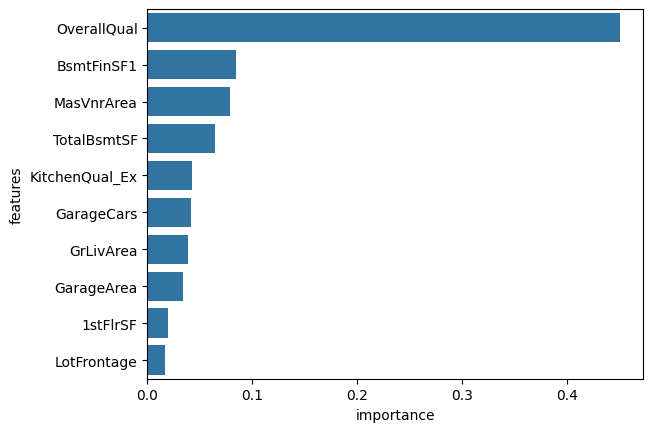

In [26]:
sns.barplot(data = importance_df.head(10), x = 'importance', y = 'features')